# 3B - Alvo: ciclo de vida e memoria dos eventos

**Pergunta especifica.** Como os eventos El Nino nascem, crescem, atingem pico e decaem na base OISST local, e quanta memoria (persistencia) a SSTA do Nino 3.4 carrega?

**Objetivo.** Caracterizar o alvo (12 eventos) antes de buscar causas: taxas, trajetorias compostas por classe e e-folding da persistencia.

**Justificativa.** O e-folding vira baseline honesto para a Fase 5; o mapa composto valida que a caixa Nino 3.4 captura o maximo do aquecimento.

**Metodologia.** Eventos = SSTA 3-meses >=0.5C por 5+ meses (base local). Trajetorias alinhadas ao pico por classe. Autocorrelacao semanal 1-78 lags. **Areas:** series na caixa Nino 3.4; mapa composto na faixa tropical 30S-30N para conferir o alvo.

**Saidas.** `phase3B_eventos_taxas.csv`, `phase3B_trajetorias_compostas.csv`, `phase3B_memoria_persistencia.csv`, `phase3B_mapa_composto_resumo.csv` + figuras.

In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, xarray as xr
import fase3_utils as u
weekly=pd.read_csv(u.FEAT/'phase3_indices_semanais.csv',parse_dates=['week_ending_sunday']).set_index('week_ending_sunday')
ev=u.load_events(); ssta=weekly['nino34_ssta']
rows=[]
for _,e in ev.iterrows():
    don=(e.peak_time-e.event_start).days/30.44; doff=(e.event_end-e.peak_time).days/30.44
    s0,sp,s1=ssta.asof(e.event_start),ssta.asof(e.peak_time),ssta.asof(e.event_end)
    rows.append({'event_id':e.event_id,'classe':e.peak_class,'pico_c':round(e.peak_monthly_ssta_c,3),'duracao_meses':e.duration_months,
     'crescimento_c_por_mes':round((sp-s0)/max(don,1e-9),3),'decaimento_c_por_mes':round((s1-sp)/max(doff,1e-9),3)})
taxas=pd.DataFrame(rows); u.save_table(taxas,'phase3B_eventos_taxas.csv',index=False); taxas

[tabela] data/processed/parquet/statistics/phase3B_eventos_taxas.csv


,event_id,classe,pico_c,duracao_meses,crescimento_c_por_mes,decaimento_c_por_mes
0,el_nino_oisst_1982_1983,super_el_nino,2.213,11,0.306,-0.470
1,el_nino_oisst_1986_1988,moderate_el_nino,1.223,16,0.048,-0.048
2,el_nino_oisst_1991_1992,strong_el_nino,1.736,10,0.325,-0.167
3,el_nino_oisst_1994_1995,weak_el_nino,1.192,5,0.428,-0.251
4,el_nino_oisst_1997_1998,super_el_nino,2.166,11,0.241,-0.249
5,el_nino_oisst_2002_2003,moderate_el_nino,1.250,8,0.173,-0.148
6,el_nino_oisst_2004,weak_el_nino,0.681,5,-0.051,-0.037
7,el_nino_oisst_2006_2007,weak_el_nino,1.128,5,0.164,0.204
8,el_nino_oisst_2009_2010,strong_el_nino,1.719,10,0.172,-0.149
9,el_nino_oisst_2014_2016,super_el_nino,2.448,19,0.188,-0.382


[tabela] data/processed/parquet/statistics/phase3B_trajetorias_compostas.csv


[figura] data/processed/figures/fase3/phase3B_trajetorias_compostas.png


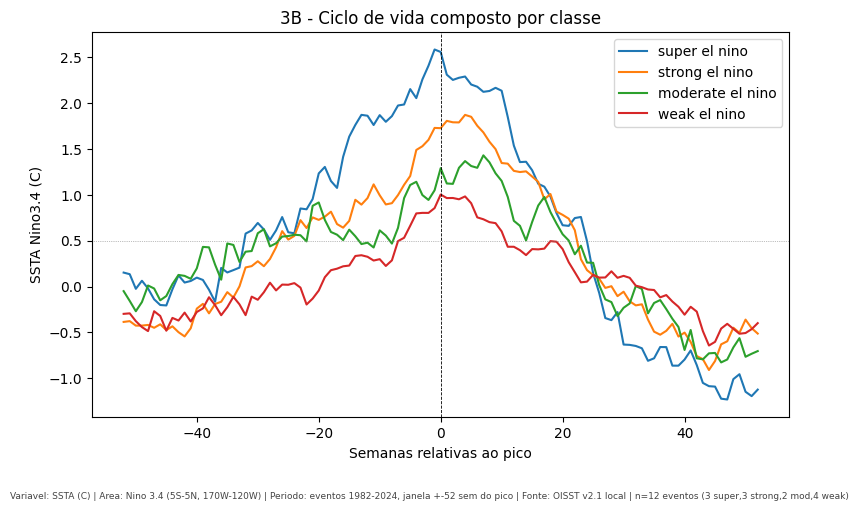

In [2]:
lags=range(-52,53); comp={}
for cls,g in ev.groupby('peak_class'):
    mm=[]
    for _,e in g.iterrows():
        i=ssta.index.get_indexer([e.peak_time],method='nearest')[0]; seg=ssta.iloc[max(0,i-52):i+53]
        rel=((seg.index-ssta.index[i]).days/7).round().astype(int); mm.append(pd.Series(seg.values,index=rel))
    comp[cls]=pd.DataFrame(mm).reindex(columns=list(lags)).mean()
comp=pd.DataFrame(comp); u.save_table(comp.rename_axis('semana_rel_pico'),'phase3B_trajetorias_compostas.csv')
fig,ax=plt.subplots(figsize=(9,5))
for cls in [c for c in ['super_el_nino','strong_el_nino','moderate_el_nino','weak_el_nino'] if c in comp]:
    ax.plot(comp.index,comp[cls],label=cls.replace('_',' '))
ax.axvline(0,color='k',ls='--',lw=.6); ax.axhline(.5,color='grey',ls=':',lw=.5); ax.legend()
ax.set_xlabel('Semanas relativas ao pico'); ax.set_ylabel('SSTA Nino3.4 (C)'); ax.set_title('3B - Ciclo de vida composto por classe')
u.stamp_caption(fig,variavel='SSTA (C)',area=u.CAIXAS['nino34'],periodo='eventos 1982-2024, janela +-52 sem do pico',
 fonte='OISST v2.1 local',n='12 eventos (3 super,3 strong,2 mod,4 weak)')
u.save_fig(fig,'phase3B_trajetorias_compostas.png'); plt.show()

[tabela] data/processed/parquet/statistics/phase3B_memoria_persistencia.csv


[figura] data/processed/figures/fase3/phase3B_autocorrelacao.png


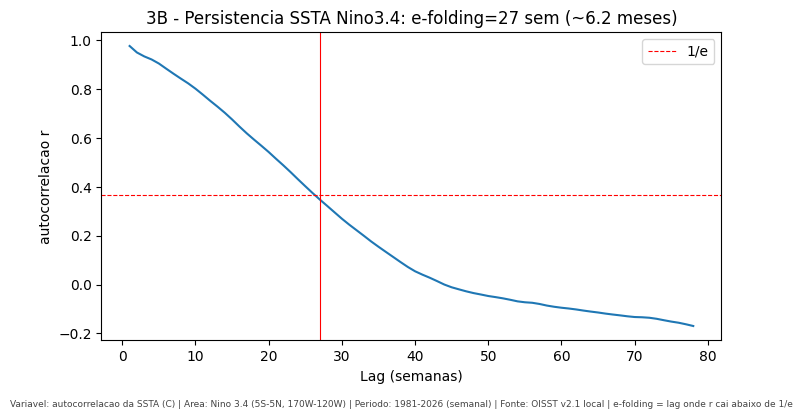

e-folding = 27 semanas


In [3]:
ac=pd.Series({lag:ssta.autocorr(lag) for lag in range(1,79)},name='autocorrelacao')
efold=int(ac[ac<1/np.e].index.min()); mem=ac.to_frame(); mem['abaixo_1_sobre_e']=mem['autocorrelacao']<1/np.e
u.save_table(mem.rename_axis('lag_semanas'),'phase3B_memoria_persistencia.csv')
fig,ax=plt.subplots(figsize=(8,4)); ax.plot(ac.index,ac.values); ax.axhline(1/np.e,color='r',ls='--',lw=.8,label='1/e'); ax.axvline(efold,color='r',lw=.8)
ax.set_xlabel('Lag (semanas)'); ax.set_ylabel('autocorrelacao r'); ax.legend(); ax.set_title(f'3B - Persistencia SSTA Nino3.4: e-folding={efold} sem (~{efold/4.33:.1f} meses)')
u.stamp_caption(fig,variavel='autocorrelacao da SSTA (C)',area=u.CAIXAS['nino34'],periodo='1981-2026 (semanal)',fonte='OISST v2.1 local',extra='e-folding = lag onde r cai abaixo de 1/e')
u.save_fig(fig,'phase3B_autocorrelacao.png'); plt.show(); print('e-folding =',efold,'semanas')

[tabela] data/processed/parquet/statistics/phase3B_mapa_composto_resumo.csv


[figura] data/processed/figures/fase3/phase3B_mapa_composto_super.png


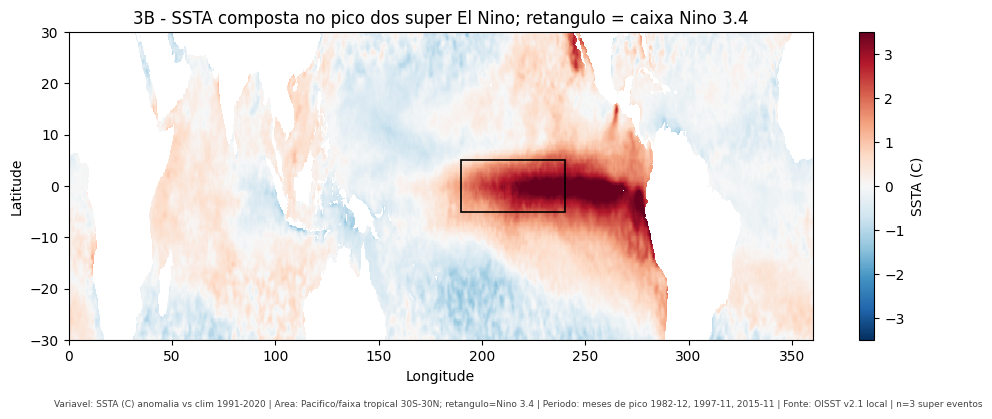

,evento,ssta_max_c,ssta_media_nino34_c
0,1982-12,4.890,2.297
1,1997-11,5.517,2.194
2,2015-11,4.299,2.811


In [4]:
MAPC=u.ROOT/'data/interim/fase3_map_cache'
def mf(y,m):
    f=MAPC/f'sst_month_{y}_{m:02d}.nc'
    if f.exists(): return xr.open_dataarray(f)
    try: ds=xr.open_zarr(u.ROOT/f'data/processed/zarr/cpc_noaa/oisst/sst.day.mean.{y}.zarr',consolidated=False)
    except Exception: ds=xr.open_dataset(u.ROOT/f'data/raw/cpc_noaa/oisst/sst.day.mean.{y}.nc')
    fld=ds['sst'].sel(time=f'{y}-{m:02d}').mean('time').sel(lat=slice(-30,30)).load(); ds.close(); return fld
peaks=[(1982,12),(1997,11),(2015,11)]; fields=[]
for y,m in peaks:
    clim=xr.concat([mf(cy,m) for cy in range(1991,2021)],'y').mean('y'); fields.append((f'{y}-{m:02d}',(mf(y,m)-clim).load()))
cf=xr.concat([f for _,f in fields],'e').mean('e')
fig,ax=plt.subplots(figsize=(12,4)); pc=ax.pcolormesh(cf.lon,cf.lat,cf.values,cmap='RdBu_r',vmin=-3.5,vmax=3.5,shading='auto')
ax.add_patch(plt.Rectangle((190,-5),50,10,fill=False,ec='k',lw=1.2)); ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('3B - SSTA composta no pico dos super El Nino; retangulo = caixa Nino 3.4')
fig.colorbar(pc,ax=ax,label='SSTA (C)')
u.stamp_caption(fig,variavel='SSTA (C) anomalia vs clim 1991-2020',area='Pacifico/faixa tropical 30S-30N; retangulo=Nino 3.4',
 periodo='meses de pico 1982-12, 1997-11, 2015-11',fonte='OISST v2.1 local',n='3 super eventos')
res=pd.DataFrame([{'evento':pk,'ssta_max_c':round(float(f.max()),3),'ssta_media_nino34_c':round(float(f.sel(lat=slice(-5,5),lon=slice(190,240)).mean()),3)} for pk,f in fields])
u.save_table(res,'phase3B_mapa_composto_resumo.csv',index=False); u.save_fig(fig,'phase3B_mapa_composto_super.png'); plt.show(); res

**Leitura do 3B.** Ciclo assimetrico: super El Ninos crescem ~0.19-0.31 C/mes e decaem mais rapido (-0.38 a -0.47 C/mes). A **persistencia (e-folding ~27 semanas ~6 meses)** e o baseline que a Fase 5 tera de superar. O mapa composto confirma o maximo dentro/adjacente a caixa Nino 3.4 (padrao Pacifico-leste): a caixa e um bom alvo.